# Technical Indicators Analysis

Calculate and visualize technical indicators.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from preprocessing.feature_engineering import add_technical_indicators, add_price_features

%matplotlib inline

In [9]:
%pip install pandas_ta --quiet

Note: you may need to restart the kernel to use updated packages.


In [11]:
# Load data (try multiple possible locations)
from pathlib import Path
ticker = 'AAPL'
candidates = [
    Path('../data/processed') / f'{ticker}_cleaned.csv',
    Path('../../../../data/processed') / f'{ticker}_cleaned.csv',
    Path('data/processed') / f'{ticker}_cleaned.csv',
    Path('../../data/processed') / f'{ticker}_cleaned.csv'
]
data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break
if data_path is None:
    raise FileNotFoundError(f'Could not find {ticker}_cleaned.csv in: {candidates}')
print('Loading cleaned CSV from:', data_path)
data = pd.read_csv(data_path, index_col=0, parse_dates=True)

# Add indicators
data = add_technical_indicators(data)
data = add_price_features(data)

data.tail()

Loading cleaned CSV from: ..\..\..\..\data\processed\AAPL_cleaned.csv
2025-12-14 19:18:13 - preprocessing.feature_engineering - INFO - Added technical indicators. Total columns: 28
2025-12-14 19:18:13 - preprocessing.feature_engineering - INFO - Added price features


,Close,High,Low,Open,Volume,"('Close', 'AAPL')","('High', 'AAPL')","('Low', 'AAPL')","('Open', 'AAPL')","('Volume', 'AAPL')",...,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,returns,log_returns,range,range_pct,gap,gap_pct,volatility
2025-12-08 00:00:00,245.380203,249.670795,245.151228,246.843586,45205800.0,277.890015,279.670013,276.149994,278.130005,38211800.0,...,5.066312,5.066312,0.0,0.0,0.0,4.519568,0.018419,1.463383,0.005964,0.0
2025-12-09 00:00:00,245.380203,249.670795,245.151228,246.843586,45205800.0,277.179993,280.029999,276.920013,278.160004,32193300.0,...,5.066312,5.066312,0.0,0.0,0.0,4.519568,0.018419,1.463383,0.005964,0.0
2025-12-10 00:00:00,245.380203,249.670795,245.151228,246.843586,45205800.0,278.779999,279.750000,276.440002,277.750000,33038300.0,...,5.066312,5.066312,0.0,0.0,0.0,4.519568,0.018419,1.463383,0.005964,0.0
2025-12-11 00:00:00,245.380203,249.670795,245.151228,246.843586,45205800.0,278.029999,279.589996,273.809998,279.100006,33248000.0,...,5.066312,5.066312,0.0,0.0,0.0,4.519568,0.018419,1.463383,0.005964,0.0
2025-12-12 00:00:00,245.380203,249.670795,245.151228,246.843586,45205800.0,278.279999,279.220001,276.820007,277.795013,38360082.0,...,5.066312,5.066312,0.0,0.0,0.0,4.519568,0.018419,1.463383,0.005964,0.0


## Moving Averages

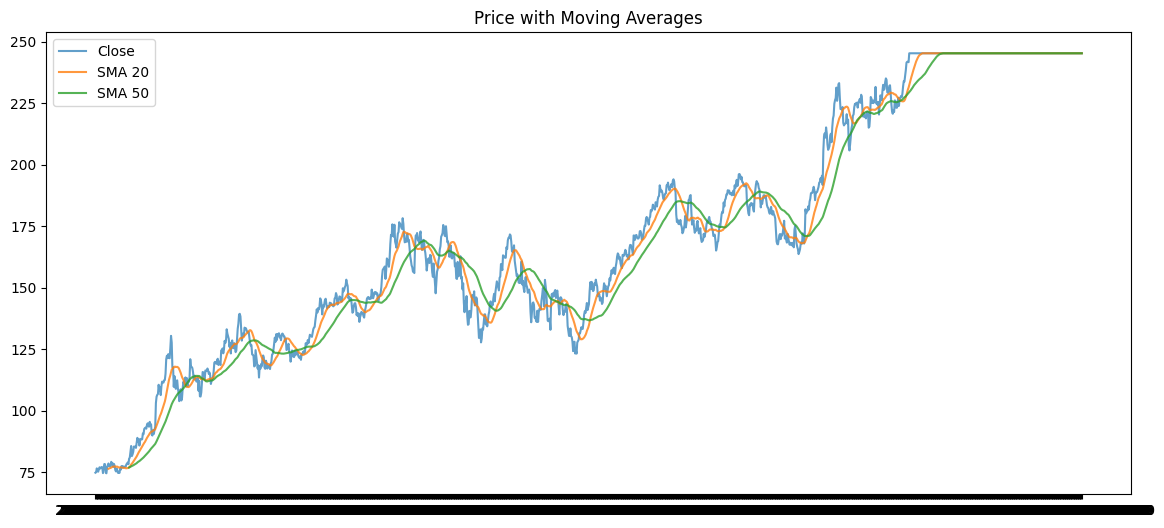

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'], label='Close', alpha=0.7)
plt.plot(data.index, data['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(data.index, data['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('Price with Moving Averages')
plt.legend()
plt.show()

## RSI

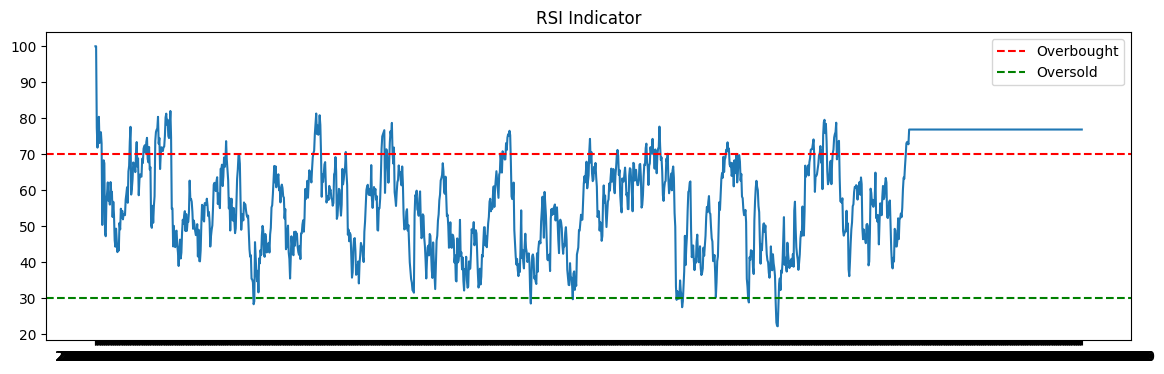

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(data.index, data['RSI'])
plt.axhline(y=70, color='r', linestyle='--', label='Overbought')
plt.axhline(y=30, color='g', linestyle='--', label='Oversold')
plt.title('RSI Indicator')
plt.legend()
plt.show()